Probabilități teoretice:
Suma 3: 0.0046
Suma 4: 0.0139
Suma 5: 0.0278
Suma 6: 0.0463
Suma 7: 0.0694
Suma 8: 0.0972
Suma 9: 0.1157
Suma 10: 0.1250
Suma 11: 0.1250
Suma 12: 0.1157
Suma 13: 0.0972
Suma 14: 0.0694
Suma 15: 0.0463
Suma 16: 0.0278
Suma 17: 0.0139
Suma 18: 0.0046

Probabilități simulate:
Suma 3: 0.0050
Suma 4: 0.0100
Suma 5: 0.0270
Suma 6: 0.0510
Suma 7: 0.0840
Suma 8: 0.1000
Suma 9: 0.1110
Suma 10: 0.1330
Suma 11: 0.1180
Suma 12: 0.1000
Suma 13: 0.0970
Suma 14: 0.0740
Suma 15: 0.0580
Suma 16: 0.0190
Suma 17: 0.0060
Suma 18: 0.0070

Numărul optim pentru cele mai bune șanse este: 10


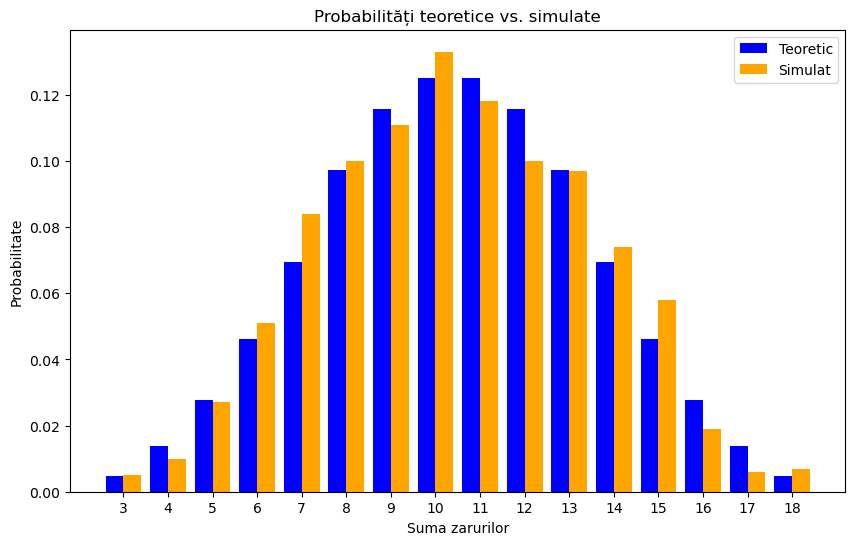

In [4]:
import random
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

def theoretical_probabilities():
    counts = Counter()
    total_combinations = 0

    for dice1 in range(1, 7):
        for dice2 in range(1, 7):
            for dice3 in range(1, 7):
                total_combinations += 1
                counts[dice1 + dice2 + dice3] += 1


    probabilities = {suma: count / total_combinations for suma, count in counts.items()}
    return probabilities

def simulate_game(rounds=1000):
    results = []

    for _ in range(rounds):
        dice_rolls = [random.randint(1, 6) for _ in range(3)]
        results.append(sum(dice_rolls))

    simulated_counts = Counter(results)
    simulated_probabilities = {suma: count / rounds for suma, count in simulated_counts.items()}
    return simulated_probabilities

def best_number(probabilities):
    return max(probabilities, key=probabilities.get)

def plot_probabilities(theoretical, simulated):
    sums = sorted(theoretical.keys())
    theoretical_values = [theoretical[s] for s in sums]
    simulated_values = [simulated.get(s, 0) for s in sums]

    x = np.arange(len(sums))

    plt.figure(figsize=(10, 6))
    plt.bar(x - 0.2, theoretical_values, width=0.4, label="Teoretic", color="blue")
    plt.bar(x + 0.2, simulated_values, width=0.4, label="Simulat", color="orange")
    plt.xticks(x, sums)
    plt.xlabel("Suma zarurilor")
    plt.ylabel("Probabilitate")
    plt.title("Probabilități teoretice vs. simulate")
    plt.legend()
    plt.show()

theoretical = theoretical_probabilities()
simulated = simulate_game(rounds=1000)

print("Probabilități teoretice:")
for suma, prob in sorted(theoretical.items()):
    print(f"Suma {suma}: {prob:.4f}")

print("\nProbabilități simulate:")
for suma, prob in sorted(simulated.items()):
    print(f"Suma {suma}: {prob:.4f}")


optimal_number = best_number(theoretical)
print(f"\nNumărul optim pentru cele mai bune șanse este: {optimal_number}")

plot_probabilities(theoretical, simulated)
